In [1]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pion-argon-xs-analysis" in root.split("/"):
        pypath = root.split("pion-argon-xs-analysis")[0] + "/pion-argon-xs-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
env: PYTHONPATH=/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis


In [2]:
import awkward as ak
import numpy as np

from iminuit import minimize
from python.analysis import cross_section, Tags, Plots, Master, vector, SelectionTools, Application
from apps.cex_analysis_input import BeamPionSelection
from apps import cex_beam_reweight
cross_section.PlotStyler.SetPlotStyle(extend_colors = True, dpi = 100)

In [3]:
cfg = Application.ApplicationArguments.ResolveConfig(cross_section.LoadConfiguration("/home/bhuller/work/analysis_new_selection/analysis_config_new_selection.json"))
ntuples = cfg.ntuple_files

In [4]:
samples = {
    "mc" : Master.Data(ntuples["mc"][0]),
    "data" : Master.Data(ntuples["data"][0])
}

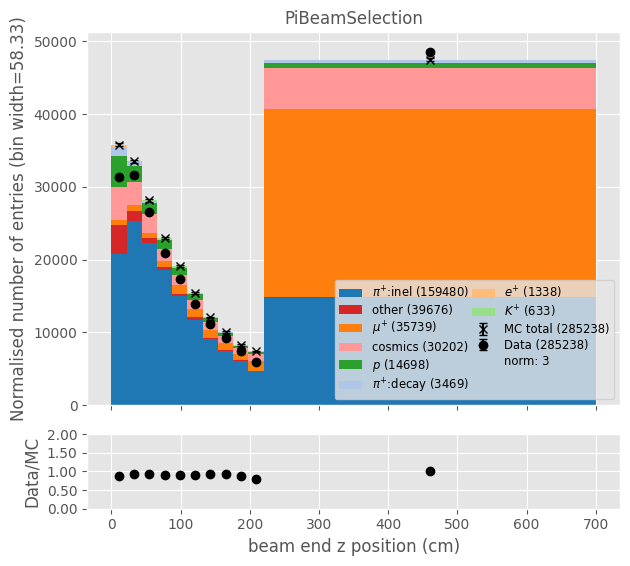

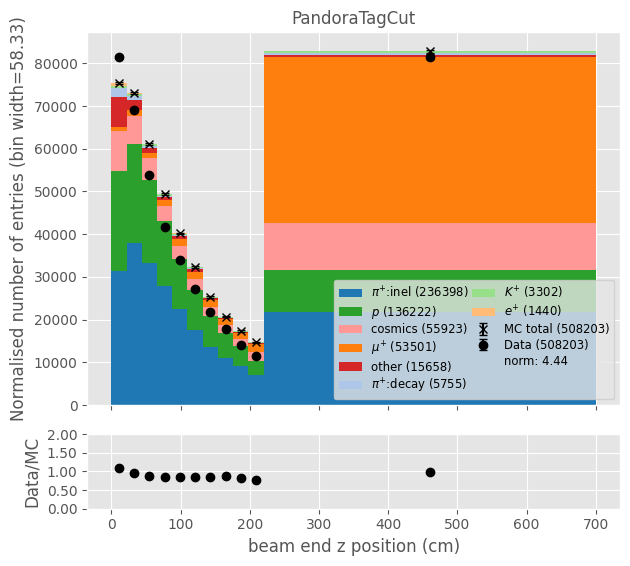

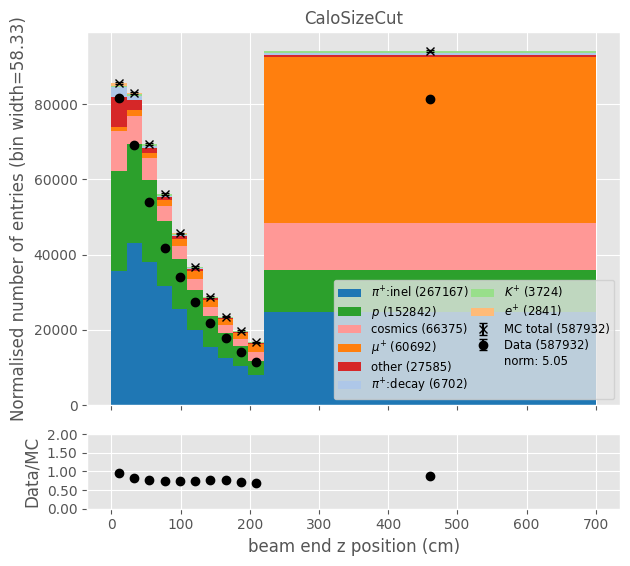

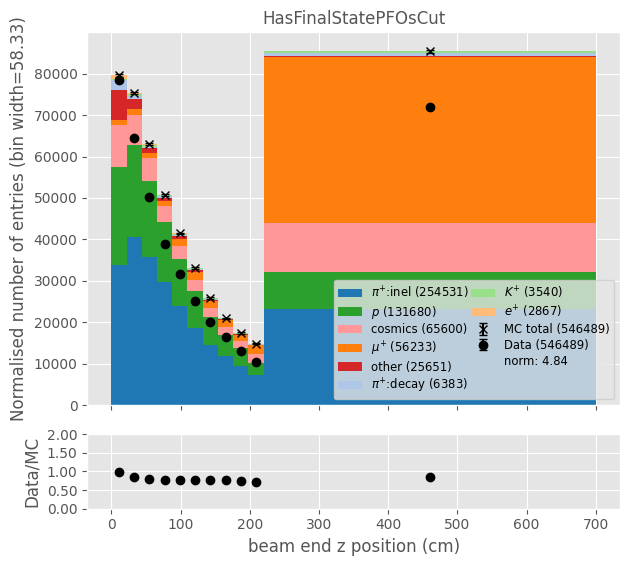

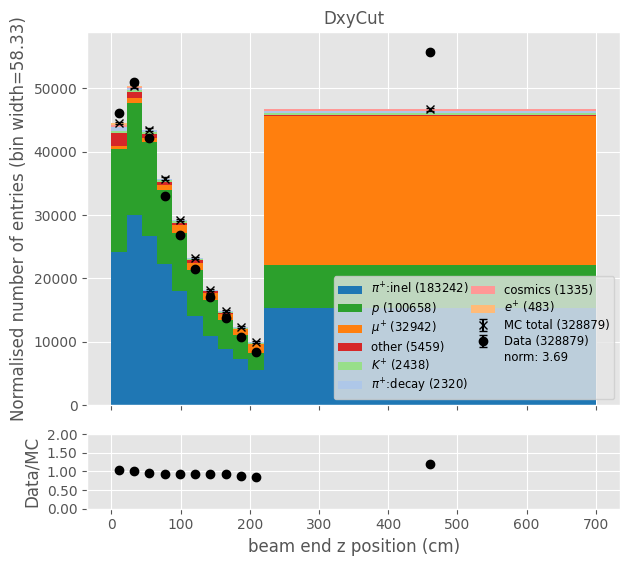

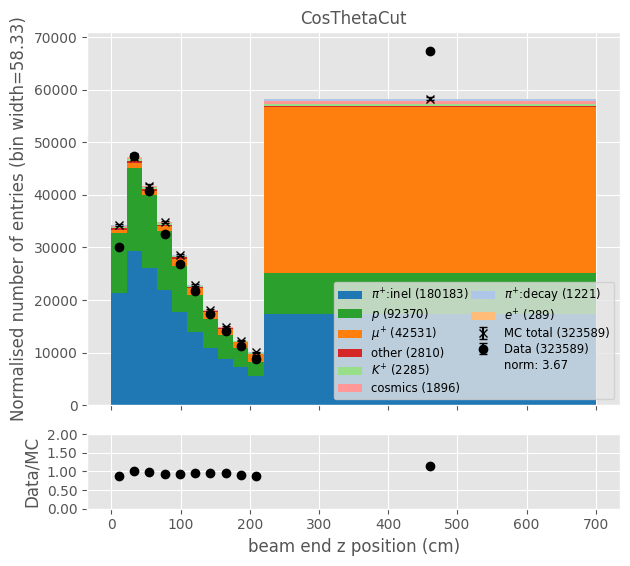

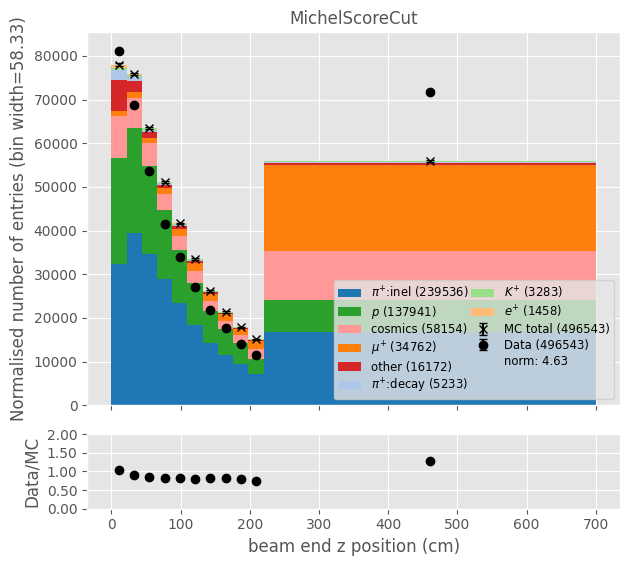

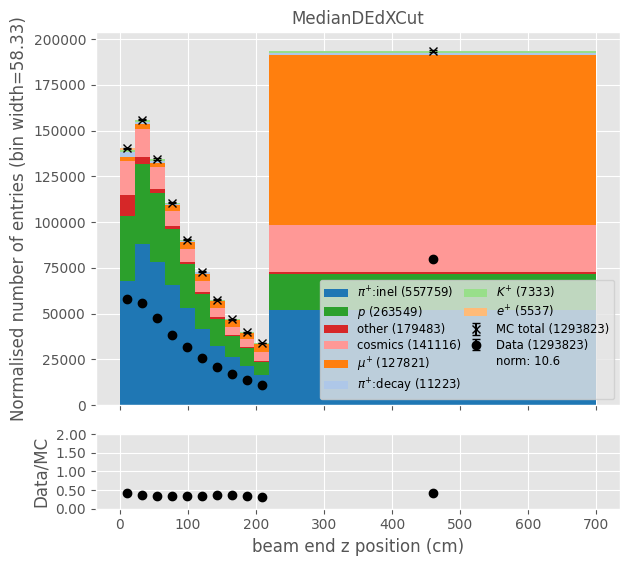

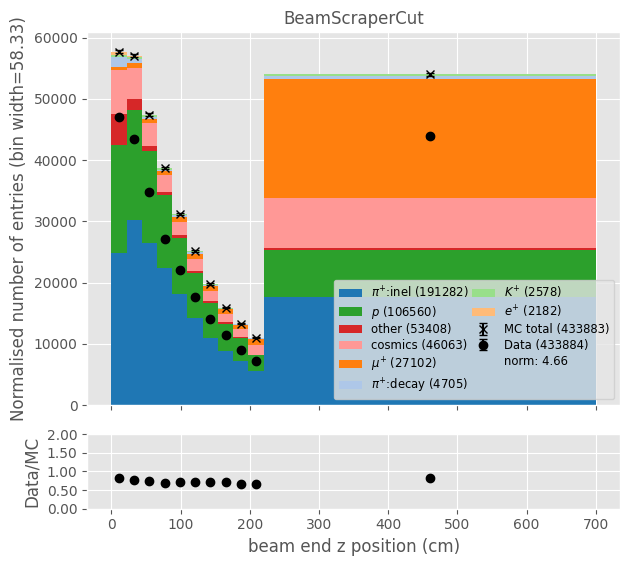

In [5]:
masks_mc = cfg.selection_masks["mc"]["beam"][samples["mc"].filename]
masks_data = cfg.selection_masks["data"]["beam"][samples["data"].filename]

z_pos_mc = samples["mc"].recoParticles.beam_endPos_SCE.z
z_pos_data = samples["data"].recoParticles.beam_endPos_SCE.z

tags = cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"])

bins = np.append(np.linspace(0, 220, 11), 700)

def update_tags(mask):
    new_tags = cross_section.copy.deepcopy(tags)
    for k in new_tags.keys():
        new_tags[k].mask = new_tags[k].mask[mask]
    return new_tags


for (k, vm), vd in zip(masks_mc.items(), masks_data.values()):
    Plots.PlotTagged(z_pos_mc[vm], update_tags(vm), data2 = z_pos_data[vd], x_label = "beam end z position (cm)", x_range = [0, 700], bins = bins, norm = True, title = k)


# cfg.selection_masks["data"]["beam"][samples["data"].filename]

pdf end_z.pdf has been opened
pdf end_z.pdf has been closed


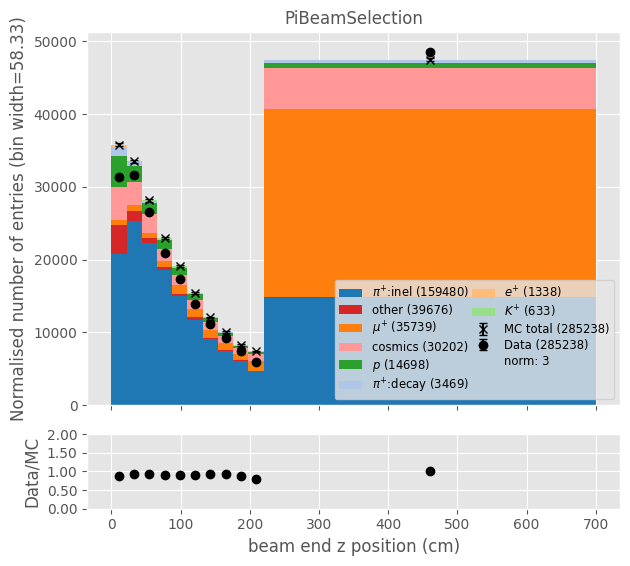

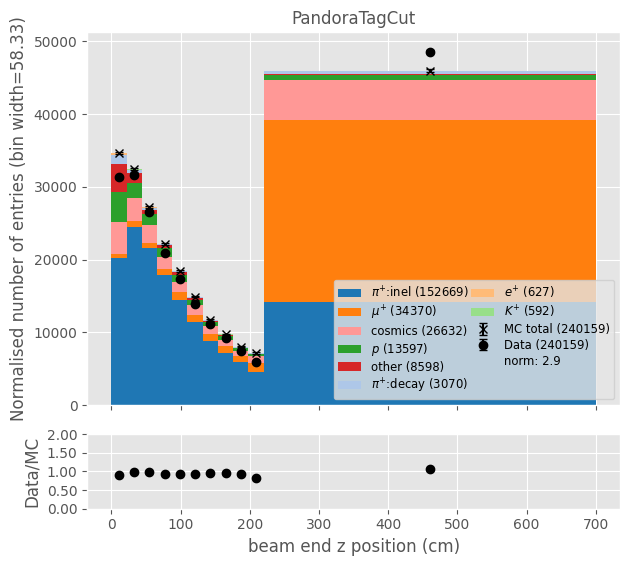

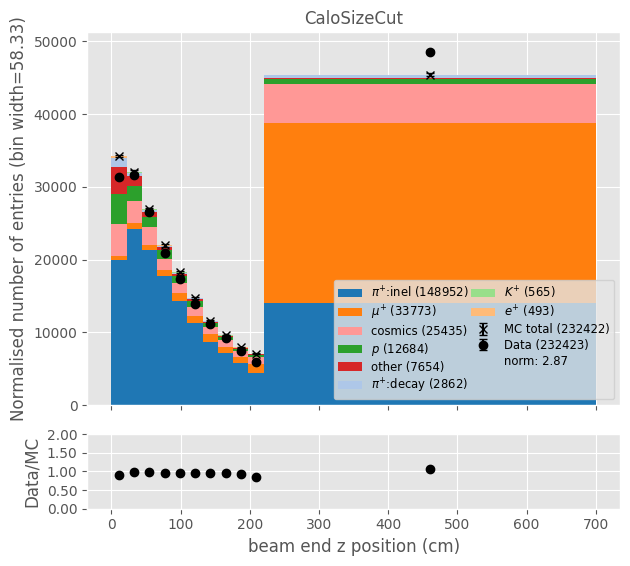

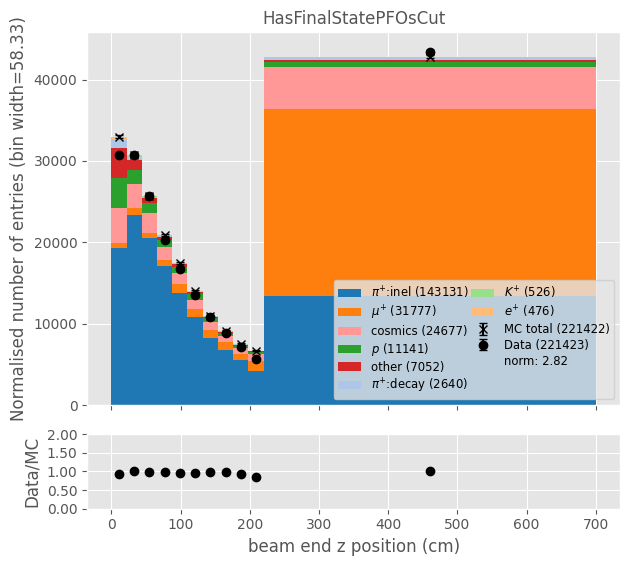

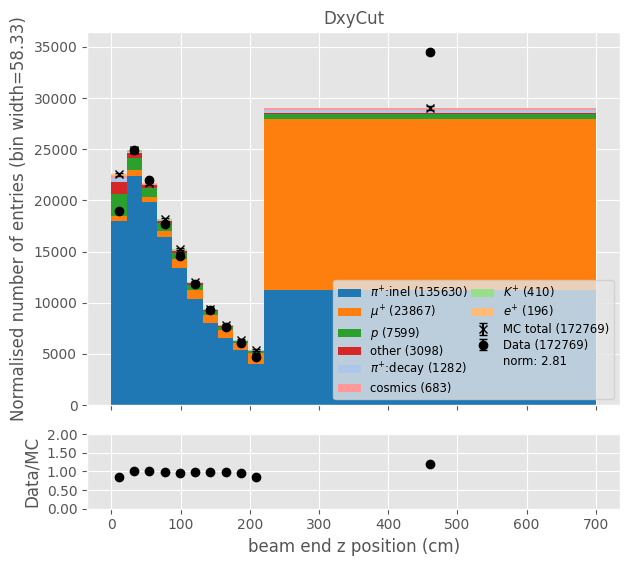

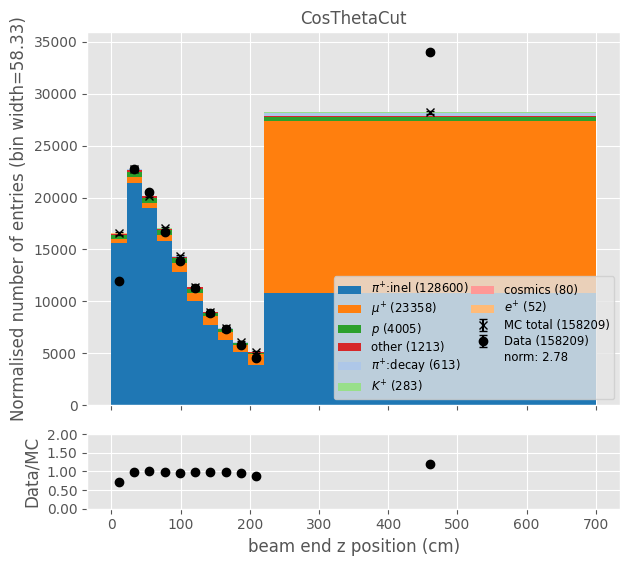

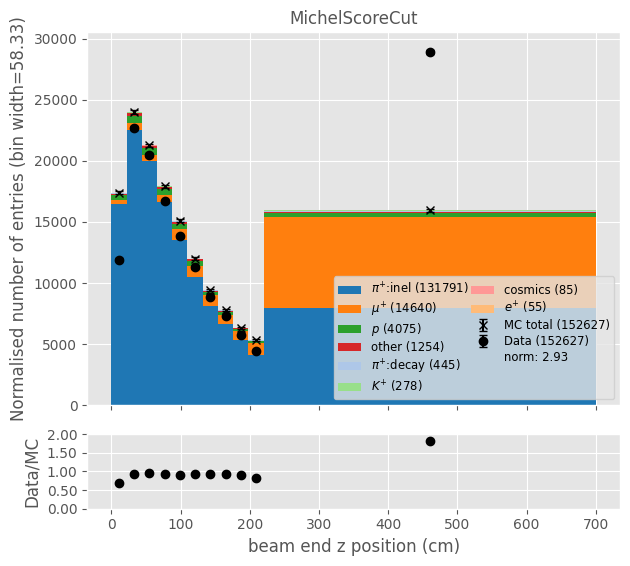

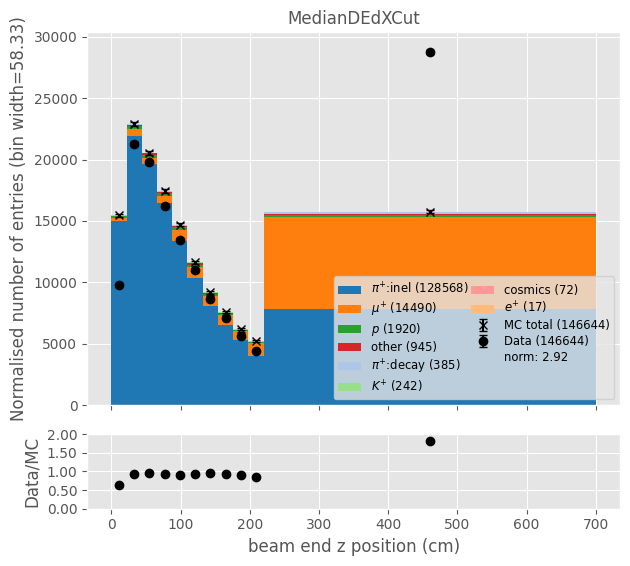

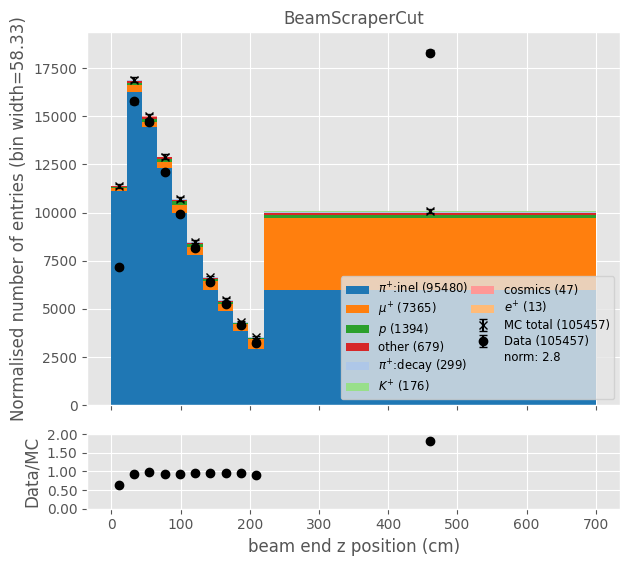

In [11]:
masks_mc = cfg.selection_masks["mc"]["beam"][samples["mc"].filename]
masks_data = cfg.selection_masks["data"]["beam"][samples["data"].filename]

z_pos_mc = samples["mc"].recoParticles.beam_endPos_SCE.z
z_pos_data = samples["data"].recoParticles.beam_endPos_SCE.z

tags = cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"])

bins = np.append(np.linspace(0, 220, 11), 700)

def update_tags(mask):
    new_tags = cross_section.copy.deepcopy(tags)
    for k in new_tags.keys():
        new_tags[k].mask = new_tags[k].mask[mask]
    return new_tags

def update_mask(current, new):
    if current is None:
        current = new
    else:
        current = current & new
    return current

current_mask_data = None
current_mask_mc = None
with Plots.PlotBook("end_z") as book:
    for (k, vm), vd in zip(masks_mc.items(), masks_data.values()):
        current_mask_mc = update_mask(current_mask_mc, vm)
        current_mask_data = update_mask(current_mask_data, vd)
        Plots.PlotTagged(z_pos_mc[current_mask_mc], update_tags(current_mask_mc), data2 = z_pos_data[current_mask_data], x_label = "beam end z position (cm)", x_range = [0, 700], bins = bins, norm = True, title = k)
        book.Save()


In [5]:
mask = samples["data"].recoParticles.beam_inst_valid
mask = mask & (samples["data"].recoParticles.beam_inst_trigger != 8)
mask = mask & (samples["data"].recoParticles.beam_inst_nTracks == 1) & (samples["data"].recoParticles.beam_inst_nMomenta == 1)
mask = mask & samples["data"].recoParticles.reco_reconstructable_beam_event


In [ ]:
book = Plots.PlotBook("sideband_study", False)

pdf sideband_study.pdf has been opened


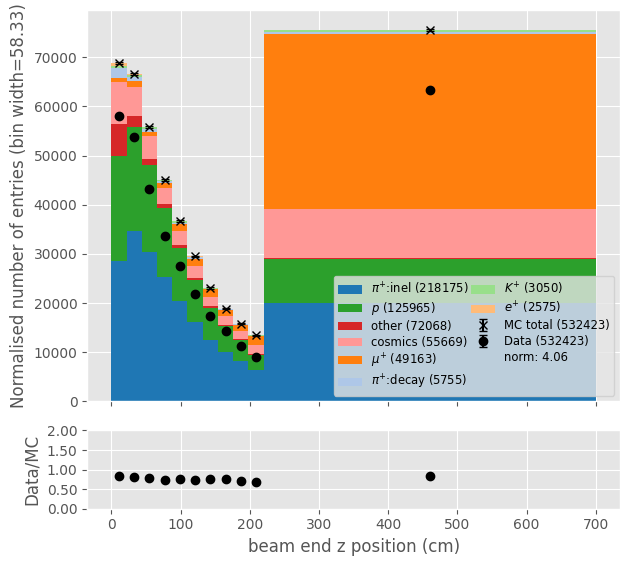

In [56]:
# Plots.PlotTagged(samples["mc"].recoParticles.beam_inst_P, cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_inst_P[mask], x_range = [1500, 2500], bins = 50, norm = True)
# book.Save()

bins = np.append(np.linspace(0, 220, 11), 700)

Plots.PlotTagged(samples["mc"].recoParticles.beam_endPos_SCE.z, cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_endPos_SCE.z[mask], x_label = "beam end z position (cm)", x_range = [0, 700], bins = bins, norm = True)
# book.Save()

In [10]:
# Plots.PlotTagged(samples["mc"].recoParticles.beam_endPos_SCE.z, Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_endPos_SCE.z[mask], x_range = [0, 100], y_scale = "linear", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)
# Plots.PlotTagged(samples["mc"].recoParticles.beam_endPos_SCE.z, Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_endPos_SCE.z[mask], x_range = [0, 100], y_scale = "log", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)

# Plots.PlotTagged(samples["mc"].recoParticles.beam_michelScore, Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_michelScore[mask], x_range = [0, 1], y_scale = "linear", truncate = True, x_label = "michel_score", norm = True, bins = 50)

In [27]:
beam_proton = {
    "mc" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["mc"], [2212], False),
    "data" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["data"], [2212], True)
    }
beam_pion = {
    "mc" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["mc"], [211, 13, -13], False),
    "data" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["data"], [211, 13, -13], True)
    }


In [57]:
def z_pos(mask):
    selected_sample = {k : v.Filter([mask[k]], [mask[k]], returnCopy = True) for k, v in samples.items()}

    return {k : v.recoParticles.beam_endPos_SCE.z for k, v in selected_sample.items()}, Tags.GenerateTrueBeamParticleTags(selected_sample["mc"])

def beam_pos(mask):
    selected_sample = {k : v.Filter([mask[k]], [mask[k]], returnCopy = True) for k, v in samples.items()}

    return {k : v.recoParticles.beam_inst_P for k, v in selected_sample.items()}, Tags.GenerateTrueBeamParticleTags(selected_sample["mc"])

def plot_z(z, tags, weights = None):
    Plots.PlotTagged(z["mc"], tags, data2 = z["data"], x_range = [0, 700], y_scale = "linear", truncate = False, x_label = "end z (cm)", norm = True, bins = bins, data_weights = weights)
    return

f=<Array [False, True, True, True, ..., False, True, True] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>
f=<Array [True, False, False, ..., True, False, False] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>


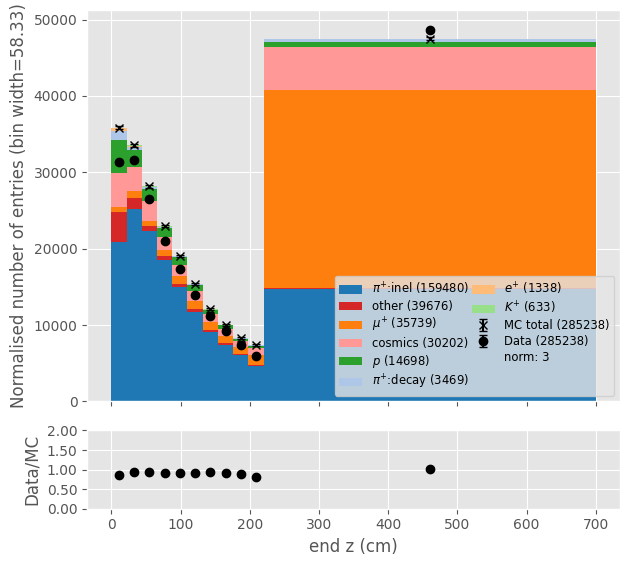

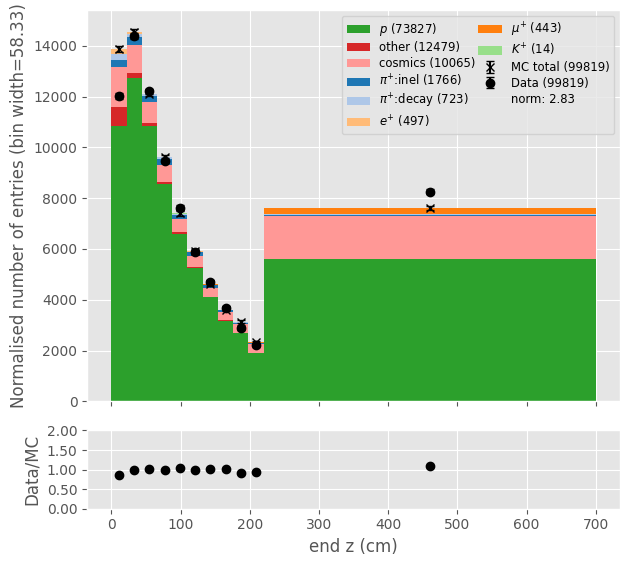

In [58]:
z_pion = z_pos(beam_pion)
z_proton = z_pos(beam_proton)

plot_z(*z_pion)
book.Save()
plot_z(*z_proton)
book.Save()

# z = {k : v[beam_proton[k]] for k, v in z.items()}
# Plots.PlotTagged(z["mc"], Tags.GenerateTrueBeamParticleTags(selected_sample["mc"]), data2 = z["data"], x_range = [0, 700], y_scale = "linear", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)
# Plots.PlotTagged(z["mc"], Tags.GenerateTrueBeamParticleTags(selected_sample["mc"]), data2 = z["data"], x_range = [0, 700], y_scale = "log", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)


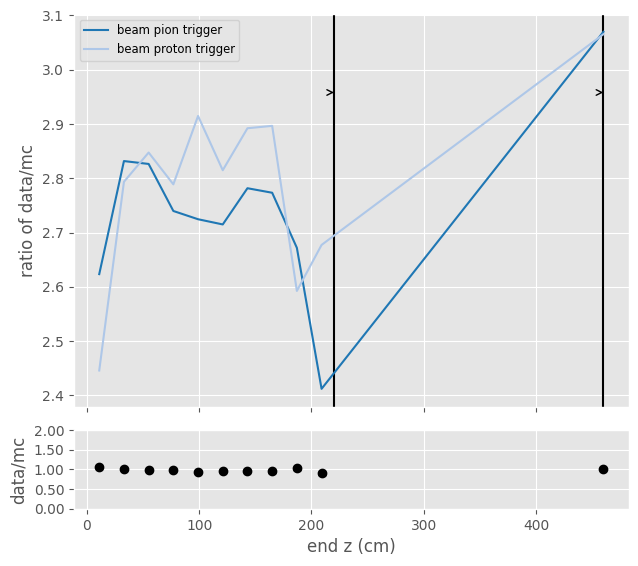

In [60]:
# bins = np.arange(0, 700, 14)
bins = np.append(np.linspace(0, 220, 11), 700)


def ratio(z):

    mc = np.histogram(z[0]["mc"], bins)[0]
    data = np.histogram(z[0]["data"], bins)[0]
    r = data / mc
    delta_r = r * (1/mc + 1/data)**0.5

    return r, delta_r

r_pion = ratio(z_pion)
r_proton = ratio(z_proton)


with Plots.RatioPlot(cross_section.bin_centers(bins), r_pion[0], r_proton[0], r_pion[1], r_proton[1], xlabel = "end z (cm)", ylabel = "data/mc") as rplot:
    Plots.Plot(rplot.x, rplot.y1, label = "beam pion trigger", ylabel = "ratio of data/mc", newFigure = False)
    Plots.Plot(rplot.x, rplot.y2, label = "beam proton trigger", newFigure = False)
    Plots.DrawCutPosition(220)
    Plots.DrawCutPosition(460)
book.Save()
# z_pion["data"] / z_pion["mc"]

In [15]:
def step_func_mask(x, boundaries, operators):
    masks = []
    for b, o in zip(boundaries, operators):
        masks.append(cross_section.SelectionTools.cuts_to_func(b, o)(x))

    return masks

def step_func(x, step, boundaries, operators):
    values = np.zeros_like(x)
    for s, b, o in zip(step, boundaries, operators):
        mask = cross_section.SelectionTools.cuts_to_func(b, o)(x)
        values = np.where(mask, s, values)
    return values

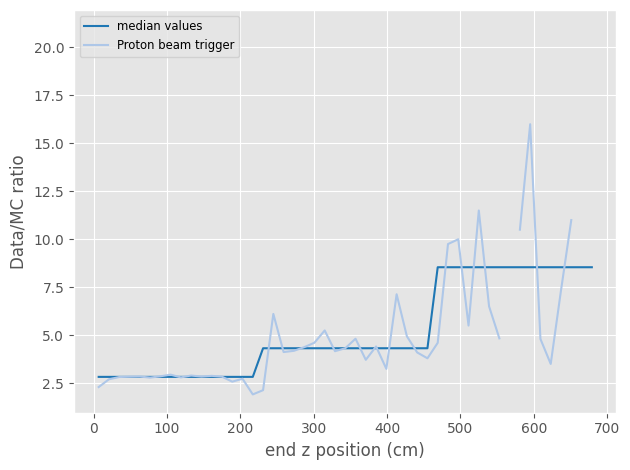

In [38]:
x = rplot.x
ratio = rplot.y2
isf = np.isfinite(ratio)


boundaries = [220, [220, 460], 460]
operators  = ["<", [">=", "<="], ">"]

masks = step_func_mask(x[isf], boundaries, operators)
sf = [np.nanmedian(ratio[isf][m]) for m in masks]

y = step_func(x, sf, boundaries, operators)

Plots.Plot(x, y, xlabel = "end z position (cm)", ylabel = "Data/MC ratio", label = "median values")
Plots.Plot(rplot.x, rplot.y2, label = "Proton beam trigger", newFigure = False)
book.Save()

In [44]:
[i/proton_ratio for i in sf]

[np.float64(0.999361172588429),
 np.float64(1.5273893366040152),
 np.float64(3.021788186617778)]

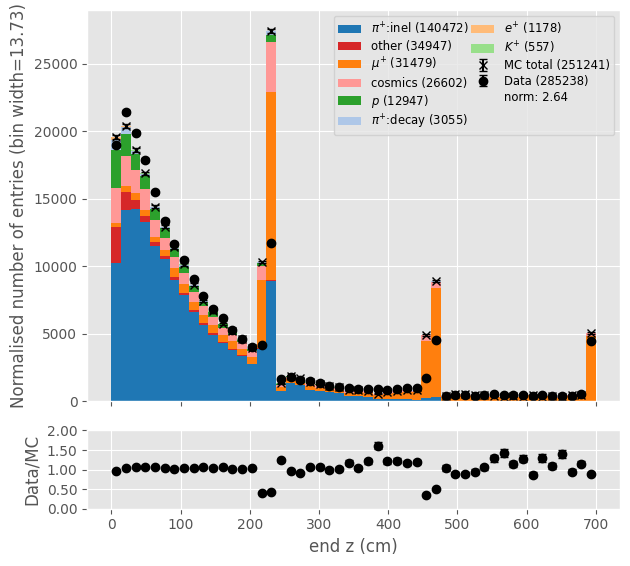

In [39]:
proton_ratio = len(z_proton[0]["data"]) / len(z_proton[0]["mc"])
y = step_func(z_pion[0]["mc"], sf, boundaries, operators) / proton_ratio

# plot_z(*z_pion)
plot_z(*z_pion, weights = y)
book.Save()

f=<Array [False, True, True, True, ..., False, True, True] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>


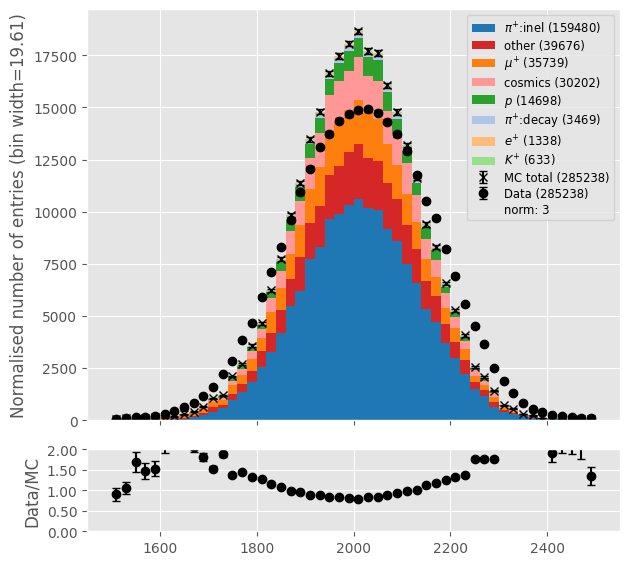

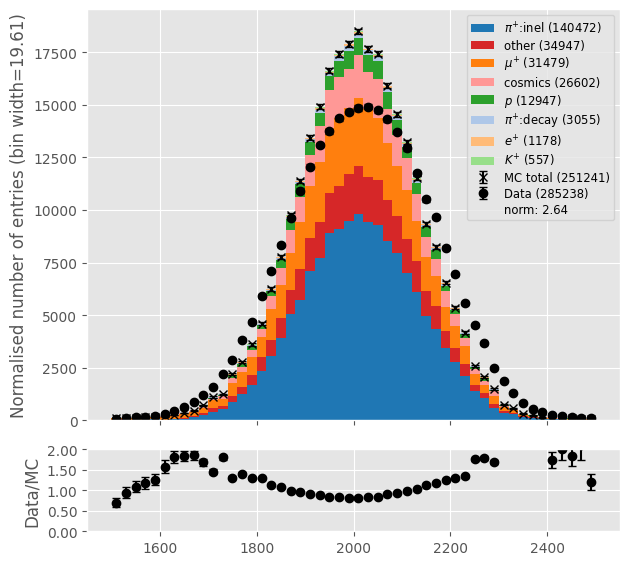

In [40]:
beam_p_pion = beam_pos(beam_pion)
Plots.PlotTagged(beam_p_pion[0]["mc"], beam_p_pion[1], data2 = beam_p_pion[0]["data"], x_range = [1500, 2500], bins = 50, norm = True, ncols = 1)
book.Save()
Plots.PlotTagged(beam_p_pion[0]["mc"], beam_p_pion[1], data2 = beam_p_pion[0]["data"], x_range = [1500, 2500], bins = 50, norm = True, data_weights = y, ncols = 1)
book.Save()

In [41]:
book.close()

pdf sideband_study.pdf has been closed


# Proton

In [24]:
beam_trigger_selection = {
    "mc" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["mc"], [2212], False),
    "data" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["data"], [2212], True)
    }

proton_sample = {k : v.Filter([beam_trigger_selection[k]], [beam_trigger_selection[k]], returnCopy = True) for k, v in samples.items()}


f=<Array [True, False, False, ..., True, False, False] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>


In [25]:
# normalisation 
n_data = ak.sum(beam_trigger_selection["data"])
n_mc = ak.sum(beam_trigger_selection["mc"])
norm = round(n_data / n_mc, 3)
print(norm)

2.827


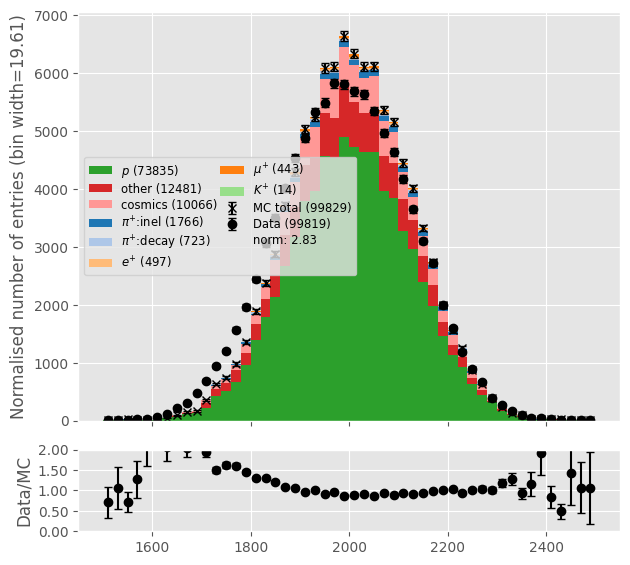

In [26]:
Plots.PlotTagged(proton_sample["mc"].recoParticles.beam_inst_P, cross_section.Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles.beam_inst_P, x_range = [1500, 2500], bins = 50, norm = norm)

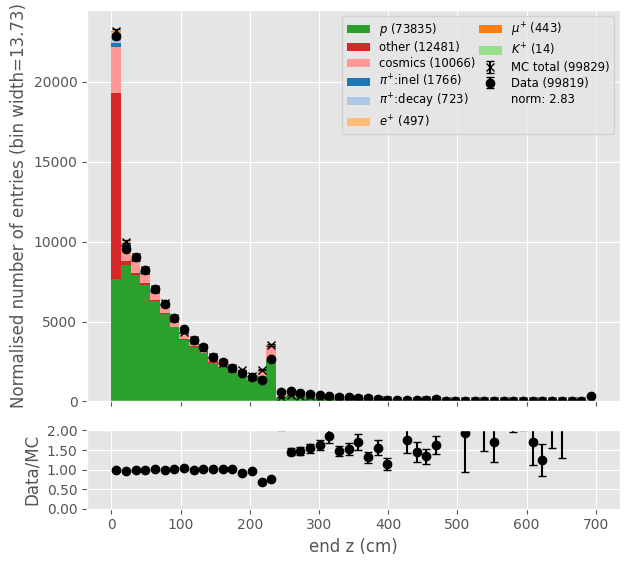

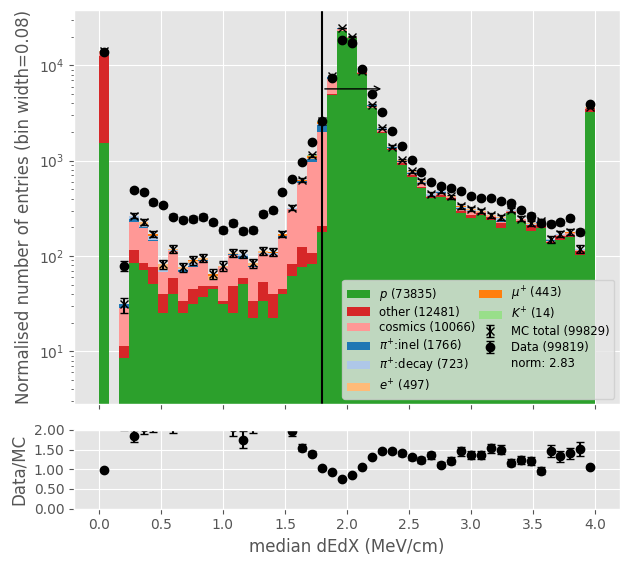

In [28]:
Plots.PlotTagged(proton_sample["mc"].recoParticles.beam_endPos_SCE.z, Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles.beam_endPos_SCE.z, x_range = [0, 700], y_scale = "linear", truncate = True, x_label = "end z (cm)", norm = norm, bins = 50)



Plots.PlotTagged(cross_section.BeamParticleSelection.Median(proton_sample["mc"].recoParticles.beam_dEdX), Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = cross_section.BeamParticleSelection.Median(proton_sample["data"].recoParticles.beam_dEdX), x_range = [0, 4], y_scale = "log", truncate = True, x_label = "median dEdX (MeV/cm)", norm = norm, bins = 50)
Plots.DrawMultiCutPosition(1.8, face = ">", arrow_length = 0.5)

In [29]:
proton_mask = {k : cross_section.BeamParticleSelection.Median(v.recoParticles.beam_dEdX) > 1.9 for k, v in proton_sample.items()}
proton_sample  = {k : v.Filter([proton_mask[k]],[proton_mask[k]], returnCopy = True) for k, v in proton_sample.items()}


f=<Array [True, False, True, True, ..., True, True, True] type='35313 * bool'>
f=<Array [True, True, True, True, ..., True, True, True] type='99819 * bool'>


In [ ]:
proton_mask = {k : cross_section.BeamParticleSelection.HasFinalStatePFOsCut(v) for k, v in proton_sample.items()}
proton_sample = {k : v.Filter([proton_mask[k]], [proton_mask[k]], returnCopy = True) for k, v in proton_sample.items()}

proton_sample = {k : v.Filter([cross_section.PFOSelection.GoodShowerSelection(v)], returnCopy = True) for k, v in proton_sample.items()}

In [ ]:
proton_sample["mc"].recoParticles.LoadData("beam_track_score", "reco_beam_PFP_trackScore", False)
proton_sample["data"].recoParticles.LoadData("beam_track_score", "reco_beam_PFP_trackScore", False)

In [ ]:
with Plots.PlotBook("1GeV_proton_sideband.pdf", True) as book:
    Plots.PlotTags(Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), xlabel = "proton sideband")
    book.Save()
    Plots.PlotBar(ak.num(proton_sample["mc"].recoParticles.number), xlabel = "number of PFOs")
    book.Save()
    Plots.PlotBar(ak.num(proton_sample["data"].recoParticles.number), xlabel = "number of PFOs")
    book.Save()
    Plots.PlotTagged(proton_sample["mc"].recoParticles.track_score, Tags.GenerateTrueParticleTagsPiPlus(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles.track_score, x_range = [0, 1], bins = 50, norm = True, x_label = "track score")
    book.Save()
    Plots.PlotHistDataMC(ak.mean(proton_sample["data"].recoParticles.track_score, axis = -1), ak.mean(proton_sample["mc"].recoParticles.track_score, axis = -1), x_range = [0, 1], bins = 21, norm = True, xlabel = "mean track score")
    book.Save()
    Plots.PlotTagged(proton_sample["mc"].recoParticles._RecoParticleData__beam_track_score, Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles._RecoParticleData__beam_track_score, norm = True, bins = 50, x_label = "beam particle track score")
    book.Save()